# Camera Degradation Health Score — Benchmark nhỏ cho ADAS
**Nhóm 10 — K4 Track4 Day04 Sensor Reality Sprint**

## Mục tiêu
Đo mức suy giảm detector khi **cùng một bộ ảnh val** bị làm lỗi cảm biến (blur / exposure / noise),
và kiểm tra xem các **proxy metric chất lượng ảnh** (blur score, exposure, entropy) có tương quan
với **detector confidence / mAP** hay không.

## Claim (giả thuyết để thử)
> Khi ảnh bị nhòe mạnh hơn (sigma tăng) hoặc phơi sáng lệch khỏi mức chuẩn,
> `lap_var` giảm, `brightness` lệch khỏi 0.5, `entropy` giảm; và `mAP@50` cùng
> confidence trung bình của detector **giảm** theo mức suy giảm.

Claim là giả thuyết, không phải kết luận.

## Metric
| Nhóm | Metric | Đơn vị |
|---|---|---|
| Chất lượng ảnh (proxy) | Laplacian variance (`lap_var`) | variance, không đơn vị |
| Chất lượng ảnh (proxy) | Mean brightness | 0..1 |
| Chất lượng ảnh (proxy) | Shannon entropy | bits |
| Chất lượng ảnh (proxy) | Health score tổng hợp | 0..1 |
| Detector | mAP@50, mAP@50-95, precision, recall | 0..1 |
| Detector | Mean max confidence, số box | 0..1, count |

**Baseline vs điều kiện lỗi dùng CÙNG metric và CÙNG ground-truth labels.** Chỉ ảnh thay đổi,
label giữ nguyên, nên chênh lệch quy về sensor chứ không phải cách đo.

## Cách chạy trên Kaggle
1. Settings → **Internet: On** (bắt buộc để tải Roboflow + weights).
2. Settings → **Accelerator: GPU T4** (nếu muốn train nhanh).
3. Thêm Secret `ROBOFLOW_API_KEY` (Add-ons → Secrets) — **không hard-code API key vào notebook**.
4. Run All. Kết quả cuối: `degradation_results.csv`, các plot, và ảnh failure case.

In [20]:
# Bật Internet trong Kaggle Settings trước khi chạy cell này.
!pip install -q ultralytics roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7087.0/8156.9 GB disk)


## 1. Cấu hình

Chỉnh các tham số ở đây. `RF_FORMAT` để `yolov8` cho an toàn; nếu project của bạn cần format khác
(ví dụ `yolo26`) thì đổi, notebook chỉ dùng `data.yaml` nên không phụ thuộc tên format.

In [21]:
import os, cv2, ast, json, math, random, shutil
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ---- Roboflow secret (KHÔNG hard-code key) ----
RF_API_KEY = "YOUR-API-KEY"
if not RF_API_KEY:
    try:
        from kaggle_secrets import UserSecretsClient
        RF_API_KEY = UserSecretsClient().get_secret("ROBOFLOW_API_KEY")
    except Exception:
        RF_API_KEY = None
assert RF_API_KEY, "Thêm Secret ROBOFLOW_API_KEY trong Kaggle (hoặc set biến môi trường)."

WORKSPACE = "guna-tmuht"
PROJECT   = "adas-oxrvp"
VERSION   = 1
RF_FORMAT = "yolov8"      # đổi nếu project yêu cầu format khác

WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
DEG_ROOT = WORK / "degraded"; DEG_ROOT.mkdir(parents=True, exist_ok=True)

# ---- Train ----
BASE_MODEL = "yolov8n.pt"
EPOCHS     = 20
IMGSZ      = 640
BATCH      = 16
RUN_NAME   = "adas_clean"

# ---- Giới hạn cho nhanh trong lớp (đặt None để dùng full) ----
SAMPLE_FOR_QUALITY = 150
MAX_VAL_IMAGES     = 200
CONF_SAMPLE        = 100

print("WORK =", WORK)

WORK = /kaggle/working


## 2. Tải dataset Roboflow

Tìm dataset trên Roboflow Universe:
- Vào https://universe.roboflow.com và tìm theo từ khoá: `adas`, `dashcam`,
  `night driving`, `adverse weather`, `rain`, `fog`, `blurred`, `low light`.
- Lọc theo **Project Type = Object Detection** và xem số ảnh / class balance trước khi chọn.
- Sau khi fork/download, lấy `workspace`, `project`, `version` và key của bạn.

In [22]:
from roboflow import Roboflow

rf = Roboflow(api_key=RF_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download(RF_FORMAT, location=str(WORK / "adas_clean_dataset"))

DATA_YAML = Path(dataset.location) / "data.yaml"
print("Dataset:", dataset.location)
print(DATA_YAML.read_text())

loading Roboflow workspace...
loading Roboflow project...
Dataset: /kaggle/working/adas_clean_dataset
names:
- animal
- autorickshaw
- bicycle
- bus
- car
- caravan
- motorcycle
- person
- rider
- traffic light
- traffic sign
- trailer
- train
- truck
- vehicle fallback
nc: 15
roboflow:
  license: CC BY 4.0
  project: adas-oxrvp
  url: https://universe.roboflow.com/guna-tmuht/adas-oxrvp/dataset/1
  version: 1
  workspace: guna-tmuht
test: ../test/images
train: ../train/images
val: ../valid/images



## 3. Kiểm tra cấu trúc dataset

In [23]:
import yaml

cfg = yaml.safe_load(DATA_YAML.read_text())
raw_names = cfg["names"]
if isinstance(raw_names, dict):
    CLASS_NAMES = [raw_names[k] for k in sorted(raw_names)]
else:
    CLASS_NAMES = list(raw_names)
NC = int(cfg.get("nc", len(CLASS_NAMES)))
print("nc =", NC, "| classes =", CLASS_NAMES)


IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def _has_images(d):
    return d.is_dir() and any(f.suffix.lower() in IMG_EXT for f in d.glob("*"))


def _to_images_dir(base):
    # nếu base chứa thư mục 'images' thì đi vào đó, ngược lại giữ base
    sub = base / "images"
    return sub if sub.is_dir() else base


def _label_dir(img_dir):
    lbl = img_dir.parent / "labels"
    if not lbl.exists():
        lbl = Path(str(img_dir).replace("images", "labels"))
    return lbl


def resolve_split(data_yaml, split):
    '''Trả về (image_dir, label_dir) tuyệt đối cho split, chấp nhận alias và dò folder.'''
    data_yaml = Path(data_yaml)
    cfg = yaml.safe_load(data_yaml.read_text())

    aliases = {
        "val":   ["val", "valid", "validation"],
        "valid": ["valid", "val", "validation"],
        "train": ["train", "training"],
        "test":  ["test", "testing"],
    }
    keys = aliases.get(split, [split])

    root = Path(cfg.get("path", data_yaml.parent))
    if not root.is_absolute():
        root = (data_yaml.parent / root).resolve()

    candidates = []
    for k in keys:
        v = cfg.get(k)
        if not v:
            continue
        if isinstance(v, dict):
            v = list(v.values())[0]
        if isinstance(v, (list, tuple)):
            v = v[0]
        p = Path(str(v))
        candidates.append(p if p.is_absolute() else (root / p))
    for k in keys:
        candidates += [root / k, root / k / "images"]

    for c in candidates:
        if c.exists():
            c = _to_images_dir(c.resolve())
            if _has_images(c):
                return c, _label_dir(c)

    for k in keys:                      # quét toàn bộ dataset
        for d in root.rglob("images"):
            if d.parent.name.lower() == k.lower() and _has_images(d):
                return d.resolve(), _label_dir(d.resolve())

    raise FileNotFoundError(
        f"Không tìm thấy ảnh cho split '{split}'. root={root}\n"
        f"Candidates đã thử: {[str(c) for c in candidates]}"
    )


for sp in ("train", "valid", "test"):
    try:
        i, l = resolve_split(DATA_YAML, sp)
        n = len([f for f in i.glob("*") if f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")])
        print(f"{sp:5s}: {n:4d} images -> {i}")
    except Exception as e:
        print(sp, "skip:", e)

nc = 15 | classes = ['animal', 'autorickshaw', 'bicycle', 'bus', 'car', 'caravan', 'motorcycle', 'person', 'rider', 'traffic light', 'traffic sign', 'trailer', 'train', 'truck', 'vehicle fallback']
train: 6927 images -> /kaggle/working/adas_clean_dataset/train/images
valid: 1980 images -> /kaggle/working/adas_clean_dataset/valid/images
test :  987 images -> /kaggle/working/adas_clean_dataset/test/images


## 4. Hàm suy giảm chất lượng (sensor degradation)

Mô phỏng các lỗi cảm biến camera ở mức pixel (cùng nội dung, chỉ đổi chất lượng):
- **Gaussian blur**: mất nét / lấy nét sai (defocus, rung nhẹ).
- **Motion blur**: nhòe do chuyển động / rolling shutter.
- **Underexposure / Overexposure**: gamma lệch, vùng tối bị đen hoặc vùng sáng bị cháy.
- **Gaussian noise**: nhiễu cảm biến khi thiếu sáng / ISO cao.

In [24]:
def gaussian_blur(img, sigma):
    if sigma <= 0:
        return img.copy()
    k = int(2 * math.ceil(3 * sigma) + 1)
    return cv2.GaussianBlur(img, (k, k), sigma)


def motion_blur(img, length):
    length = int(length)
    if length <= 1:
        return img.copy()
    kernel = np.zeros((length, length), np.float32)
    kernel[length // 2, :] = 1.0
    kernel /= kernel.sum()
    return cv2.filter2D(img, -1, kernel)


def exposure(img, gamma=1.0, gain=1.0):
    x = img.astype(np.float32) / 255.0
    x = np.clip(x, 0, 1) ** gamma
    x = np.clip(x * gain, 0, 1)
    return (x * 255).astype(np.uint8)


def add_noise(img, sigma):
    if sigma <= 0:
        return img.copy()
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


# degradation_key -> (tên hiển thị, [các mức], hàm, đơn vị)
# Mức index 0 = giá trị "sạch" cho từng họ (dùng để sanity check với baseline).
DEGRADATIONS = {
    "blur_sigma":  ("Gaussian blur",  [0.0, 1.0, 2.0, 3.5, 5.5], lambda im, v: gaussian_blur(im, v), "sigma"),
    "motion_blur": ("Motion blur",    [1, 3, 7, 11, 15],         lambda im, v: motion_blur(im, v),   "kernel"),
    "expo_dark":   ("Underexposure",  [1.0, 1.4, 1.9, 2.5, 3.2], lambda im, v: exposure(im, gamma=v), "gamma"),
    "expo_bright": ("Overexposure",   [1.0, 0.8, 0.65, 0.5, 0.4],lambda im, v: exposure(im, gamma=v), "gamma"),
    "gauss_noise": ("Sensor noise",   [0, 5, 10, 20, 35],        lambda im, v: add_noise(im, v),     "sigma"),
}
print(list(DEGRADATIONS.keys()))

['blur_sigma', 'motion_blur', 'expo_dark', 'expo_bright', 'gauss_noise']


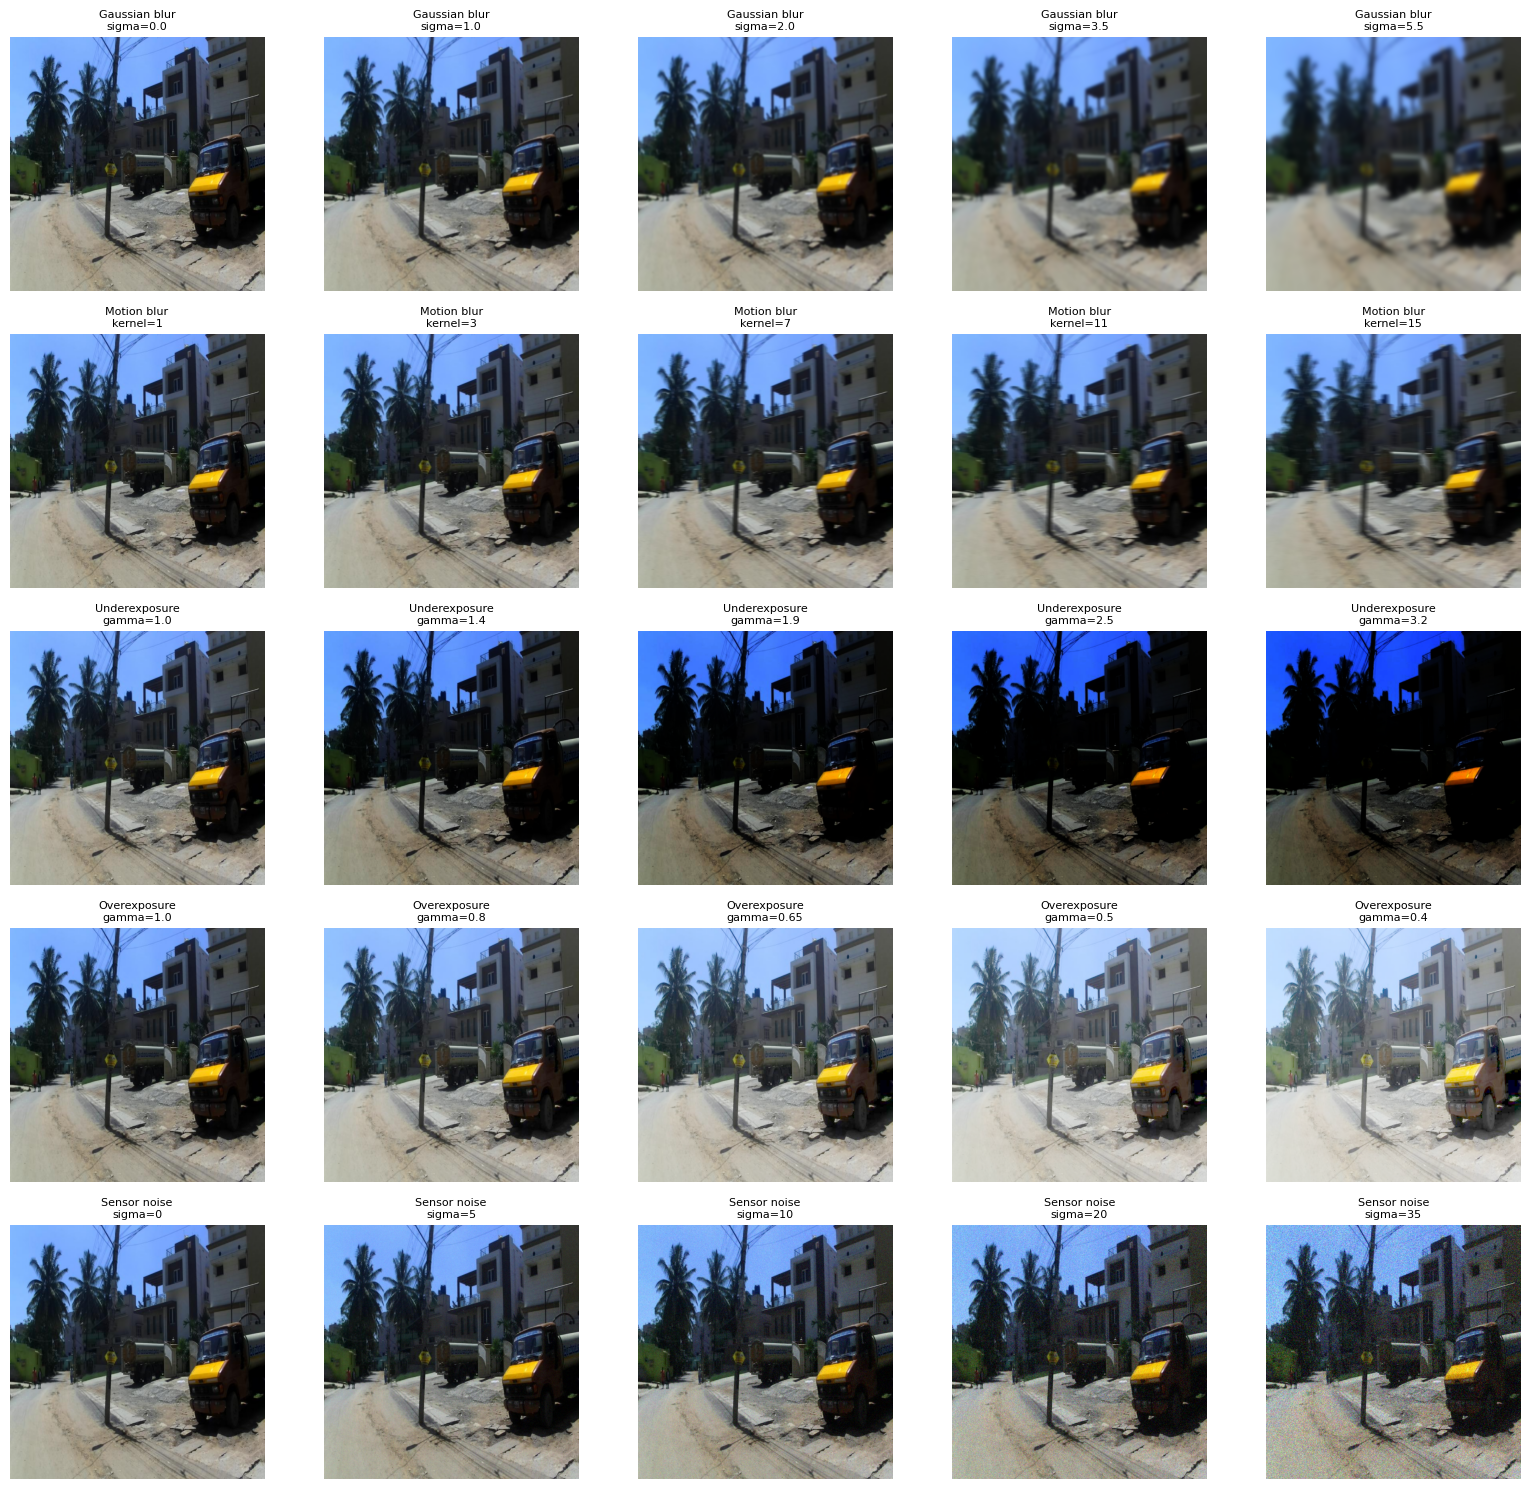

In [25]:
# Xem thử ảnh sạch và các mức suy giảm trên 1 ảnh mẫu
val_img_dir, _ = resolve_split(DATA_YAML, "valid")
sample_path = sorted([p for p in val_img_dir.glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")])[0]
base = cv2.imread(str(sample_path))

fig, axes = plt.subplots(len(DEGRADATIONS), 5, figsize=(16, 3 * len(DEGRADATIONS)))
for r, (key, (name, vals, fn, unit)) in enumerate(DEGRADATIONS.items()):
    for c, v in enumerate(vals):
        out = fn(base, v)
        axes[r, c].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        axes[r, c].set_title(f"{name}\n{unit}={v}", fontsize=8)
        axes[r, c].axis("off")
plt.tight_layout(); plt.show()

## 5. Proxy metric chất lượng ảnh + health score

Đây là "cảm biến đo sức khoẻ camera". Mỗi sub-score chuẩn hoá theo giá trị baseline (ảnh sạch),
nên health ~ 1 ở baseline và giảm khi ảnh suy giảm.

In [26]:
def laplacian_var(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def shannon_entropy(gray):
    h = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    p = h / h.sum()
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def quality_metrics(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return dict(
        lap_var=laplacian_var(gray),
        entropy=shannon_entropy(gray),
        brightness=float(gray.mean() / 255.0),
        contrast=float(gray.std() / 255.0),
        clip_low=float((gray <= 5).mean()),
        clip_high=float((gray >= 250).mean()),
    )


def mean_quality(img_dir, n=SAMPLE_FOR_QUALITY):
    files = sorted([p for p in Path(img_dir).glob("*")
                    if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")])
    if n:
        files = files[:n]
    rows = [quality_metrics(cv2.imread(str(p))) for p in tqdm(files, desc="quality", leave=False)]
    return pd.DataFrame(rows).mean().to_dict()


def health_scores(q, ref):
    blur_h = min(1.0, q["lap_var"] / max(ref["lap_var"], 1e-6))
    expo_h = math.exp(-((q["brightness"] - 0.5) / 0.30) ** 2) * (1 - q["clip_low"] - q["clip_high"])
    expo_h = max(0.0, float(expo_h))
    ent_h = min(1.0, q["entropy"] / max(ref["entropy"], 1e-6))
    return dict(blur_health=blur_h, exposure_health=expo_h, entropy_health=ent_h,
                health=(blur_h + expo_h + ent_h) / 3.0)


REF_Q = mean_quality(resolve_split(DATA_YAML, "valid")[0])
print("Reference (clean):", json.dumps(REF_Q, indent=2))
print("Reference health:", json.dumps(health_scores(REF_Q, REF_Q), indent=2))

quality:   0%|          | 0/150 [00:00<?, ?it/s]

Reference (clean): {
  "lap_var": 615.4932085184,
  "entropy": 7.438291495641073,
  "brightness": 0.3754191008603962,
  "contrast": 0.2669585706433342,
  "clip_low": 0.03661472981770834,
  "clip_high": 0.02266575520833334
}
Reference health: {
  "blur_health": 1.0,
  "exposure_health": 0.7917107656699182,
  "entropy_health": 1.0,
  "health": 0.930570255223306
}


## 6. Tạo các bộ val bị suy giảm (label giữ nguyên)

Mỗi mức tạo một thư mục ảnh mới + copy y label gốc + `data.yaml` riêng.
Detector được `val()` trên từng bộ bằng **cùng hàm metric**.

In [27]:
def build_degraded_split(split, deg_key, value, out_root=DEG_ROOT):
    img_dir, lbl_dir = resolve_split(DATA_YAML, split)
    name, vals, fn, unit = DEGRADATIONS[deg_key]
    imgs = sorted([p for p in img_dir.glob("*")
                   if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")])
    if MAX_VAL_IMAGES:
        imgs = imgs[:MAX_VAL_IMAGES]
    out = Path(out_root) / f"{deg_key}_{str(value).replace('.', 'p')}"
    oi, ol = out / "images", out / "labels"
    oi.mkdir(parents=True, exist_ok=True); ol.mkdir(parents=True, exist_ok=True)
    for p in tqdm(imgs, desc=f"{deg_key}={value}", leave=False):
        img = cv2.imread(str(p))
        cv2.imwrite(str(oi / p.name), fn(img, value))
        lp = lbl_dir / (p.stem + ".txt")
        if lp.exists():
            shutil.copy(lp, ol / lp.name)
    yml = dict(path=str(out.resolve()), train="images", val="images", nc=NC, names=CLASS_NAMES)
    yp = out / "data.yaml"
    yp.write_text(yaml.safe_dump(yml, allow_unicode=True))
    return yp, oi


# thử 1 mức
yp, oi = build_degraded_split("valid", "blur_sigma", 3.5)
print("Built:", yp)
print("Files:", len(list(oi.glob('*'))))

blur_sigma=3.5:   0%|          | 0/200 [00:00<?, ?it/s]

Built: /kaggle/working/degraded/blur_sigma_3p5/data.yaml
Files: 200


## 7. Load model "vừa train"

**Cách 1 — dùng weights đã upload ở tab Input** (Kaggle Model tên `yolov8`):
weights nằm read-only trong `/kaggle/input/<model-slug>/...` (slug thường chính là `yolov8`,
và có thể có thêm thư mục con). Đừng gọi `YOLO("yolov8")` — tên đó sẽ tải COCO pretrained,
**không phải** model của bạn. Luôn dùng đường dẫn file `.pt`.

**Cách 2 — không có input thì train mới** trên bộ sạch.

In [28]:
from ultralytics import YOLO

RUN_DIR = WORK / "runs"


def find_uploaded_weights():
    hits = list(Path("/kaggle/input").rglob("*.pt"))
    # ưu tiên best.pt, rồi tới last.pt, rồi file ngắn nhất
    hits.sort(key=lambda p: (p.name != "best.pt", p.name != "last.pt", len(p.parts)))
    return hits


RUN_DIR = WORK / "runs"
uploaded = find_uploaded_weights()
print("Tìm thấy .pt trong /kaggle/input:", uploaded)

if uploaded:
    weights = uploaded[0]
    print("=> Dùng weights upload:", weights)
    model = YOLO(str(weights))
else:
    weights = RUN_DIR / RUN_NAME / "weights" / "best.pt"
    if not weights.exists():
        YOLO(BASE_MODEL).train(
            data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
            project=str(RUN_DIR), name=RUN_NAME, seed=SEED, exist_ok=True, plots=True,
        )
        weights = RUN_DIR / RUN_NAME / "weights" / "best.pt"
    model = YOLO(str(weights))

print("Weights:", weights, "| exists:", weights.exists())
print("model.names:", model.names)

Tìm thấy .pt trong /kaggle/input: [PosixPath('/kaggle/input/models/huy1805/yolov8/pytorch/default/1/best (1).pt')]
=> Dùng weights upload: /kaggle/input/models/huy1805/yolov8/pytorch/default/1/best (1).pt
Weights: /kaggle/input/models/huy1805/yolov8/pytorch/default/1/best (1).pt | exists: True
model.names: {0: 'animal', 1: 'autorickshaw', 2: 'bicycle', 3: 'bus', 4: 'car', 5: 'caravan', 6: 'motorcycle', 7: 'person', 8: 'rider', 9: 'traffic light', 10: 'traffic sign', 11: 'trailer', 12: 'train', 13: 'truck', 14: 'vehicle fallback'}


In [29]:
# Kiểm tra nhanh model load đúng và chạy được trên 1 ảnh val
val_img_dir, _ = resolve_split(DATA_YAML, "valid")
one = sorted([p for p in val_img_dir.glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")])[0]
r = model.predict(str(one), imgsz=IMGSZ, verbose=False)[0]
print("Predict OK:", one.name, "| boxes:", 0 if r.boxes is None else len(r.boxes))

Predict OK: BLR-2018-05-29_10-59-01_sideRight_0001320_jpg.rf.ffbd37d5e1d83421c56f9a465cac0232.jpg | boxes: 5


## 8. Hàm đánh giá (dùng chung cho mọi điều kiện)

In [30]:
model = YOLO(str(weights))


def evaluate(yaml_path):
    m = model.val(data=str(yaml_path), split="val", imgsz=IMGSZ, batch=BATCH,
                  verbose=False, plots=False, save_json=False)
    return dict(mAP50=float(m.box.map50), mAP50_95=float(m.box.map),
                precision=float(m.box.mp), recall=float(m.box.mr))


def conf_stats(img_dir, n=CONF_SAMPLE):
    files = sorted([p for p in Path(img_dir).glob("*")
                    if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")])
    if n:
        files = files[:n]
    confs, counts = [], []
    for p in tqdm(files, desc="conf", leave=False):
        r = model.predict(str(p), imgsz=IMGSZ, verbose=False)[0]
        b = r.boxes
        counts.append(0 if b is None else len(b))
        if b is not None and len(b):
            confs.append(float(b.conf.max()))
    return float(np.mean(confs)) if confs else 0.0, float(np.mean(counts))


# Baseline "thật": val trên chính bộ sạch
baseline = evaluate(DATA_YAML)
base_q = mean_quality(resolve_split(DATA_YAML, "valid")[0])
baseline.update(degradation="clean", label="Clean", level=0, value=0, unit="-")
baseline.update(base_q)
baseline.update(health_scores(base_q, REF_Q))
baseline["mean_conf"], baseline["mean_boxes"] = conf_stats(resolve_split(DATA_YAML, "valid")[0])
print(pd.Series(baseline))

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1434.7±378.2 MB/s, size: 45.5 KB)
val: Scanning /kaggle/working/adas_clean_dataset/valid/labels... 1980 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1980/1980 1.2Kit/s 1.6s0.0s
val: /kaggle/working/adas_clean_dataset/valid/images/BLR-2018-06-22-05-05-26_part_45_0001125_jpg.rf.4be9b4ae284dce4bf55f9ac965cdecc8.jpg: 1 duplicate labels removed
val: New cache created: /kaggle/working/adas_clean_dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 124/124 8.2it/s 15.1s0.1s
                   all       1980      36694      0.553      0.346      0.362      0.234
Speed: 0.8ms preprocess, 3.5ms inference, 0.0ms loss, 1.1ms postprocess per image


quality:   0%|          | 0/150 [00:00<?, ?it/s]

conf:   0%|          | 0/100 [00:00<?, ?it/s]

mAP50                0.361575
mAP50_95             0.234002
precision            0.552537
recall               0.345535
degradation             clean
label                   Clean
level                       0
value                       0
unit                        -
lap_var            615.493209
entropy              7.438291
brightness           0.375419
contrast             0.266959
clip_low             0.036615
clip_high            0.022666
blur_health               1.0
exposure_health      0.791711
entropy_health            1.0
health                0.93057
mean_conf            0.940652
mean_boxes               4.36
dtype: object


## 9. Quét toàn bộ degradation × severity

In [31]:
rows = [baseline]

for deg_key, (name, vals, fn, unit) in DEGRADATIONS.items():
    for level, v in enumerate(vals):
        yp, img_out = build_degraded_split("valid", deg_key, v)
        res = evaluate(yp)
        q = mean_quality(img_out)
        res.update(degradation=deg_key, label=name, level=level, value=v, unit=unit)
        res.update(q)
        res.update(health_scores(q, REF_Q))
        res["mean_conf"], res["mean_boxes"] = conf_stats(img_out)
        rows.append(res)
        print(f"{name:15s} level={level} {unit}={v:<5} "
              f"mAP50={res['mAP50']:.3f} conf={res['mean_conf']:.3f} health={res['health']:.3f}")

df = pd.DataFrame(rows)
CSV = WORK / "degradation_results.csv"
df.to_csv(CSV, index=False)
print("Saved:", CSV)
df.round(3)

blur_sigma=0.0:   0%|          | 0/200 [00:00<?, ?it/s]

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2103.5±494.0 MB/s, size: 93.0 KB)
val: Scanning /kaggle/working/degraded/blur_sigma_0p0/labels... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 1.2Kit/s 0.2s<0.2s
val: New cache created: /kaggle/working/degraded/blur_sigma_0p0/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 7.9it/s 1.7s0.1s
                   all        200       1183      0.826      0.414      0.466       0.32
Speed: 0.8ms preprocess, 3.8ms inference, 0.0ms loss, 1.0ms postprocess per image


quality:   0%|          | 0/150 [00:00<?, ?it/s]

conf:   0%|          | 0/100 [00:00<?, ?it/s]

Gaussian blur   level=0 sigma=0.0   mAP50=0.466 conf=0.941 health=0.931


...

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3140.5±704.2 MB/s, size: 355.7 KB)
val: Scanning /kaggle/working/degraded/gauss_noise_35/labels... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 1.2Kit/s 0.2s<0.2s
val: New cache created: /kaggle/working/degraded/gauss_noise_35/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 7.6it/s 1.7s0.1s
                   all        200       1183      0.555     0.0667     0.0862     0.0556
Speed: 0.9ms preprocess, 3.9ms inference, 0.0ms loss, 0.8ms postprocess per image


quality:   0%|          | 0/150 [00:00<?, ?it/s]

conf:   0%|          | 0/100 [00:00<?, ?it/s]

Sensor noise    level=4 sigma=35    mAP50=0.086 conf=0.619 health=0.939
Saved: /kaggle/working/degradation_results.csv


,mAP50,mAP50_95,precision,recall,degradation,label,level,value,unit,lap_var,...,brightness,contrast,clip_low,clip_high,blur_health,exposure_health,entropy_health,health,mean_conf,mean_boxes
0,0.362,0.234,0.553,0.346,clean,Clean,0,0.00,-,615.493,...,0.375,0.267,0.037,0.023,1.000,0.792,1.000,0.931,0.941,4.36
1,0.466,0.320,0.826,0.414,blur_sigma,Gaussian blur,0,0.00,sigma,616.001,...,0.375,0.267,0.036,0.022,1.000,0.792,1.000,0.931,0.941,4.37
2,0.521,0.342,0.881,0.394,blur_sigma,Gaussian blur,1,1.00,sigma,55.063,...,0.375,0.262,0.032,0.020,0.089,0.798,1.000,0.629,0.953,4.17
3,0.388,0.267,0.831,0.351,blur_sigma,Gaussian blur,2,2.00,sigma,9.445,...,0.375,0.257,0.027,0.017,0.015,0.805,1.000,0.607,0.944,4.06
4,0.298,0.203,0.683,0.295,blur_sigma,Gaussian blur,3,3.50,sigma,3.134,...,0.375,0.251,0.022,0.014,0.005,0.811,1.000,0.605,0.903,3.15
5,0.223,0.151,0.624,0.205,blur_sigma,Gaussian blur,4,5.50,sigma,2.024,...,0.375,0.244,0.017,0.012,0.003,0.817,1.000,0.607,0.887,1.72
6,0.466,0.320,0.826,0.414,motion_blur,Motion blur,0,1.00,kernel,616.001,...,0.375,0.267,0.036,0.022,1.000,0.792,1.000,0.931,0.941,4.37
7,0.516,0.336,0.820,0.430,motion_blur,Motion blur,1,3.00,kernel,215.696,...,0.375,0.265,0.034,0.021,0.350,0.795,1.000,0.715,0.945,4.24
8,0.361,0.254,0.749,0.371,motion_blur,Motion blur,2,7.00,kernel,105.102,...,0.375,0.261,0.030,0.020,0.171,0.800,1.000,0.657,0.922,3.59
9,0.281,0.197,0.695,0.277,motion_blur,Motion blur,3,11.00,kernel,72.118,...,0.375,0.257,0.027,0.018,0.117,0.804,1.000,0.640,0.882,2.75


## 10. Sanity check + plot kết quả

    degradation  mAP50  mAP50_95  precision  recall  health
0         clean  0.362     0.234      0.553   0.346   0.931
1    blur_sigma  0.466     0.320      0.826   0.414   0.931
6   motion_blur  0.466     0.320      0.826   0.414   0.931
11    expo_dark  0.466     0.320      0.826   0.414   0.931
16  expo_bright  0.466     0.320      0.826   0.414   0.931
21  gauss_noise  0.466     0.320      0.826   0.414   0.931


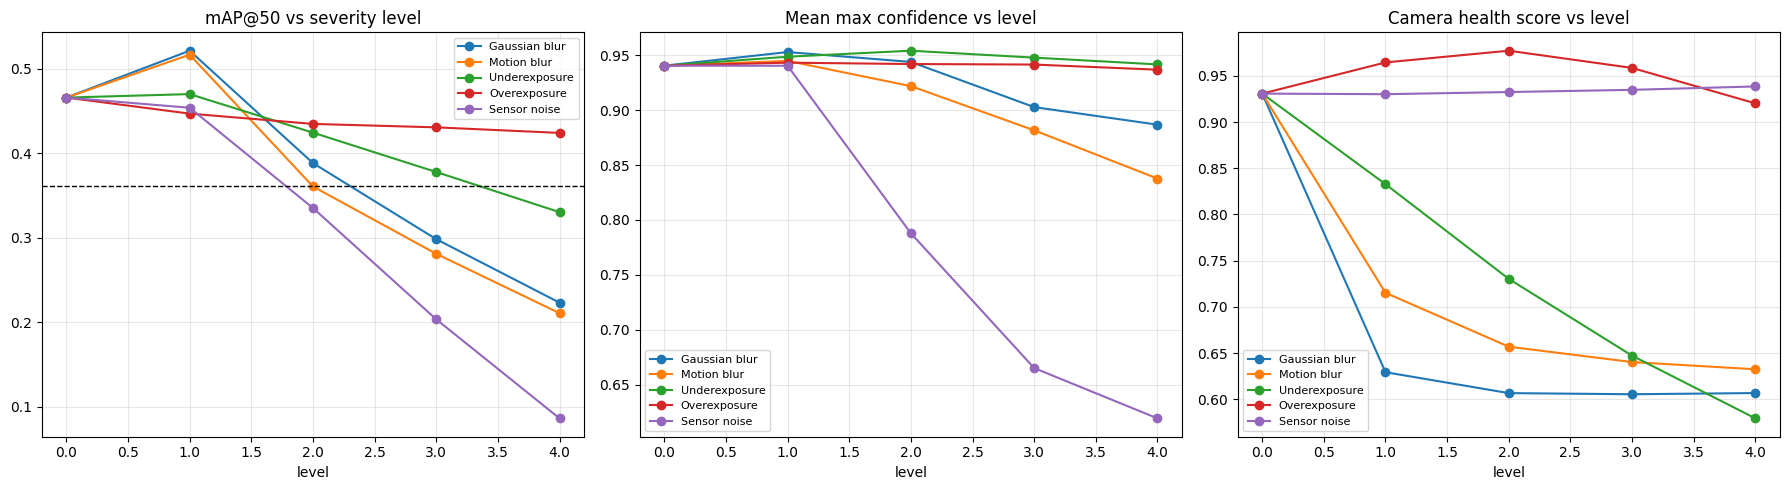

In [32]:
# Sanity: level 0 của mỗi họ ~ baseline (delta metric ~ 0 vì ảnh gần như không đổi)
level0 = df[df["level"] == 0]
print(level0[["degradation", "mAP50", "mAP50_95", "precision", "recall", "health"]].round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for key, (name, vals, fn, unit) in DEGRADATIONS.items():
    sub = df[df["degradation"] == key].sort_values("level")
    if sub.empty:
        continue
    axes[0].plot(sub["level"], sub["mAP50"], marker="o", label=name)
    axes[1].plot(sub["level"], sub["mean_conf"], marker="o", label=name)
    axes[2].plot(sub["level"], sub["health"], marker="o", label=name)
axes[0].axhline(baseline["mAP50"], ls="--", c="k", lw=1)
axes[0].set_title("mAP@50 vs severity level"); axes[0].set_xlabel("level")
axes[1].set_title("Mean max confidence vs level"); axes[1].set_xlabel("level")
axes[2].set_title("Camera health score vs level"); axes[2].set_xlabel("level")
for a in axes:
    a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(WORK / "curves.png", dpi=120); plt.show()

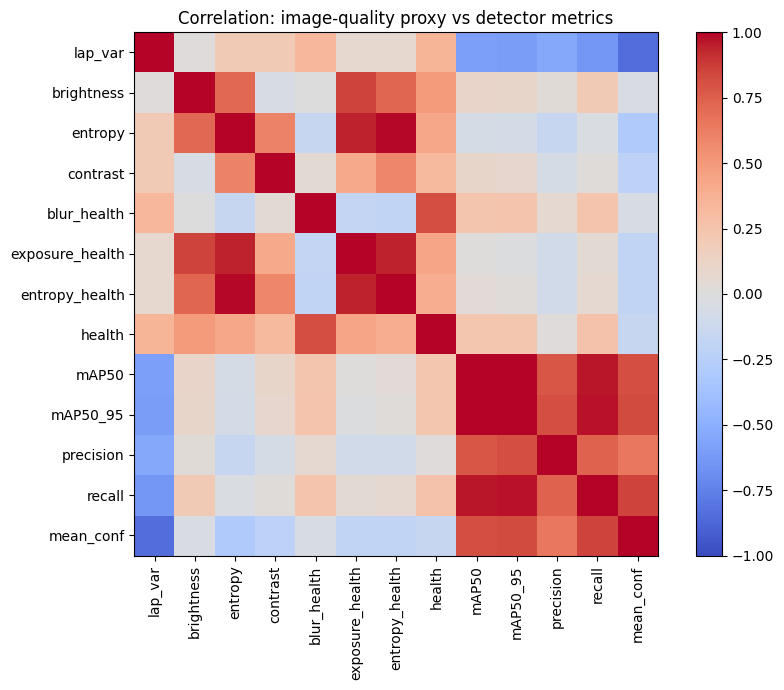

Correlation của health proxy với mAP50:
lap_var           -0.592
entropy           -0.055
exposure_health    0.003
entropy_health     0.034
contrast           0.099
brightness         0.103
health             0.228
blur_health        0.241
precision          0.787
mean_conf          0.811
recall             0.965
mAP50_95           0.997
Name: mAP50, dtype: float64


In [33]:
# Tương quan giữa proxy chất lượng và detector
cols = ["lap_var", "brightness", "entropy", "contrast", "blur_health", "exposure_health",
        "entropy_health", "health", "mAP50", "mAP50_95", "precision", "recall", "mean_conf"]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation: image-quality proxy vs detector metrics")
plt.tight_layout(); plt.savefig(WORK / "correlation.png", dpi=120); plt.show()

print("Correlation của health proxy với mAP50:")
print(corr["mAP50"].drop("mAP50").round(3).sort_values())

## 11. Failure case

Tìm ảnh mà detector **tự tin ở baseline nhưng tụt confidence mạnh** khi bị suy giảm.
Đây là bằng chứng định tính cho báo cáo.

failure:   0%|          | 0/200 [00:00<?, ?it/s]

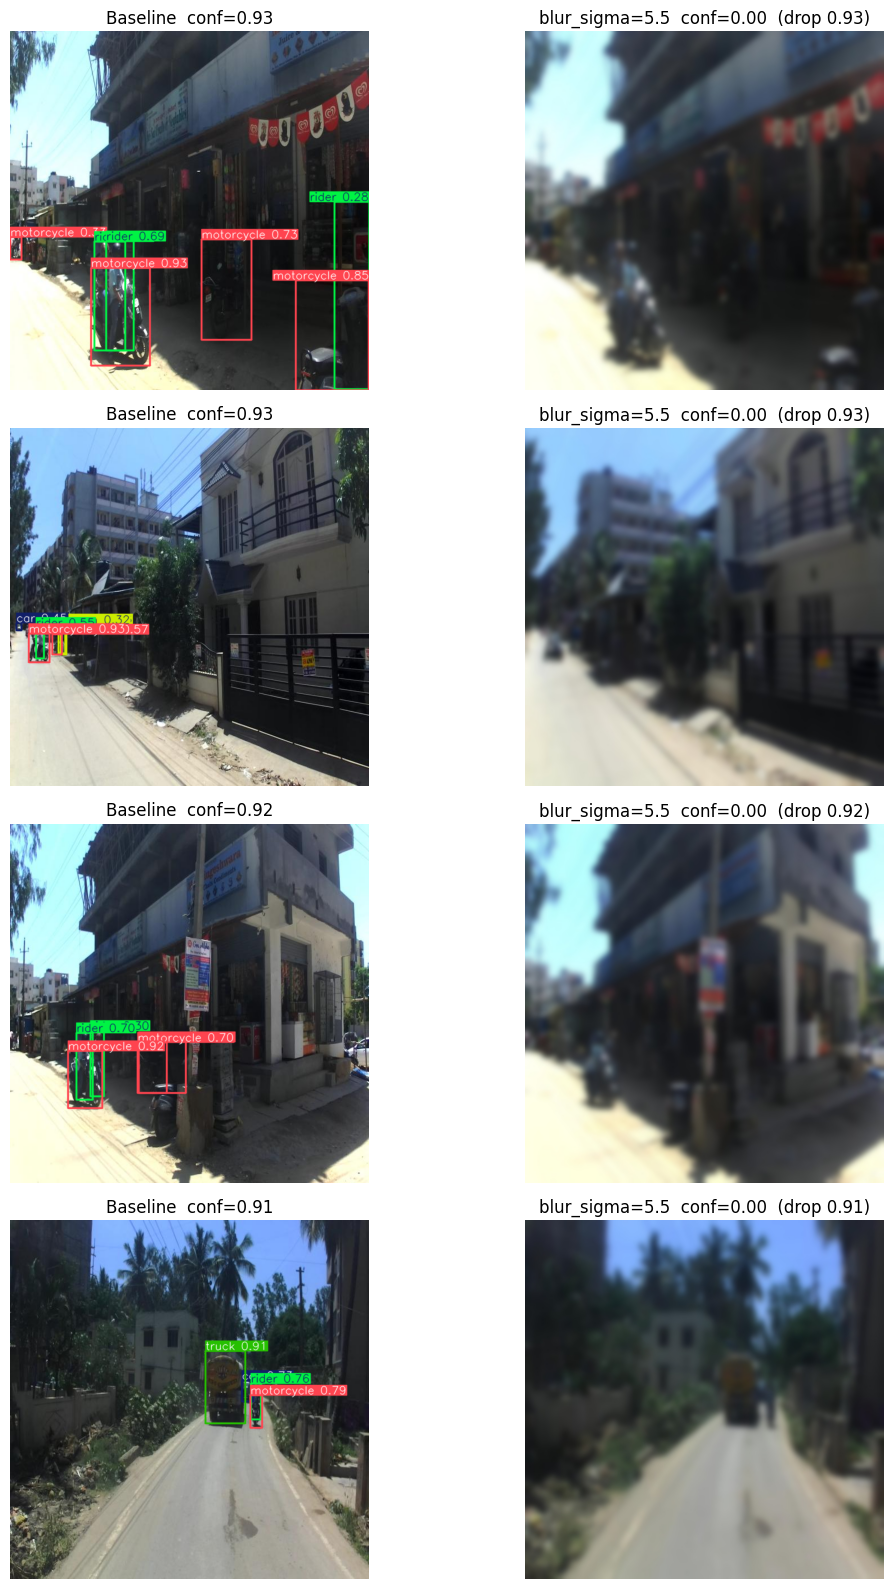

Artifacts: degradation_results.csv, curves.png, correlation.png, failure_cases.png


In [34]:
def failure_cases(deg_key, value, n=4):
    clean_dir, _ = resolve_split(DATA_YAML, "valid")
    deg_dir = DEG_ROOT / f"{deg_key}_{str(value).replace('.', 'p')}" / "images"
    names = sorted([p.name for p in deg_dir.glob("*")
                    if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")])
    diffs = []
    for nm in tqdm(names, desc="failure", leave=False):
        cp = clean_dir / nm
        if not cp.exists():
            continue
        rc = model.predict(str(cp), imgsz=IMGSZ, verbose=False)[0]
        rd = model.predict(str(deg_dir / nm), imgsz=IMGSZ, verbose=False)[0]
        cc = float(rc.boxes.conf.max()) if rc.boxes is not None and len(rc.boxes) else 0.0
        cd = float(rd.boxes.conf.max()) if rd.boxes is not None and len(rd.boxes) else 0.0
        diffs.append((cc - cd, nm, cc, cd, rc, rd))
    diffs.sort(reverse=True, key=lambda x: x[0])
    return diffs[:n]


key, value = "blur_sigma", 5.5
cases = failure_cases(key, value, n=4)
fig, axes = plt.subplots(len(cases), 2, figsize=(12, 4 * len(cases)))
if len(cases) == 1:
    axes = axes[None, :]
for r, (drop, nm, cc, cd, rc, rd) in enumerate(cases):
    axes[r, 0].imshow(cv2.cvtColor(rc.plot(), cv2.COLOR_BGR2RGB))
    axes[r, 0].set_title(f"Baseline  conf={cc:.2f}")
    axes[r, 1].imshow(cv2.cvtColor(rd.plot(), cv2.COLOR_BGR2RGB))
    axes[r, 1].set_title(f"{key}={value}  conf={cd:.2f}  (drop {drop:.2f})")
    for a in axes[r]:
        a.axis("off")
plt.tight_layout(); plt.savefig(WORK / "failure_cases.png", dpi=120); plt.show()

import shutil as _sh
_sh.make_archive(str(WORK / "degraded_outputs"), "zip", str(WORK), "degradation_results.csv")
print("Artifacts: degradation_results.csv, curves.png, correlation.png, failure_cases.png")

## 12. Tổng hợp cho báo cáo (điền số thực tế sau khi chạy)

| Mục | Nội dung |
|---|---|
| Nền tảng / tính năng | Xe ADAS — object detection (YOLO) |
| Sensor / failure case | Camera — blur, exposure lệch, sensor noise |
| Claim | Khi blur tăng / exposure lệch → `lap_var`, `entropy` giảm, `brightness` lệch 0.5 → `mAP@50` & confidence giảm |
| Metric & đơn vị | `lap_var` (variance), brightness (0..1), entropy (bits), health (0..1), mAP@50 (0..1), mean conf (0..1) |
| Baseline vs lỗi | Cùng val set, cùng labels, cùng hàm `val()`; chỉ ảnh bị suy giảm |
| Failure case | Ảnh tụt confidence mạnh khi blur/exposure xấu (xem `failure_cases.png`) |
| Đề xuất cải tiến | (1) Augment train bằng đúng họ suy giảm này; (2) dùng health score làm tín hiệu cảnh báo/fallback; (3) ngưỡng confidence động theo health |

**Kết luận cần lấy từ `degradation_results.csv`:**
- Mức suy giảm nào làm `mAP@50` rơi nhiều nhất?
- `health`/`lap_var` tương quan với `mAP50` bao nhiêu (xem `correlation.png`)?
- Có mức nào detector *bền* bất ngờ (ví dụ noise) — đó là trade-off để giải thích.